# Exploratory Data Analysis (EDA)

Analyze patterns in electricity prices and their relationships with generation and weather data.

## Goals:
1. Understand price distributions and volatility patterns
2. Identify correlations between prices and features
3. Discover seasonal and temporal patterns
4. Compare DE-LU vs ES market characteristics
5. Identify key features for modeling

In [13]:
# Install dependencies
%pip install -q pandas numpy matplotlib seaborn scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from scipy import stats

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

print("✅ Imports successful!")

✅ Imports successful!


## 1. Load Data

In [15]:
from src.data.loaders import EnergyChartsLoader, WeatherDataLoader

# Initialize loaders
energy_loader = EnergyChartsLoader(cache_dir=Path('../data/raw'))
weather_loader = WeatherDataLoader(cache_dir=Path('../data/external'))

# Date range for analysis
start_date = '2026-01-01'
end_date = '2026-05-05'
zones = ['DE-LU', 'ES']

print(f"Loading data from {start_date} to {end_date}")

Loading data from 2026-01-01 to 2026-05-05


In [16]:
# Load all data for both zones
data = {}

for zone in zones:
    print(f"\n{'='*60}")
    print(f"Loading data for {zone}")
    print(f"{'='*60}")
    
    # Load prices
    df_prices = energy_loader.load_day_ahead_prices(
        zone=zone,
        start_date=start_date,
        end_date=end_date,
        use_cache=True
    )
    
    # Load generation
    df_generation = energy_loader.load_generation_data(
        zone=zone,
        start_date=start_date,
        end_date=end_date,
        use_cache=True
    )
    
    # Load weather
    df_weather = weather_loader.load_weather_data(
        zone=zone,
        start_date=start_date,
        end_date=end_date,
        use_cache=True
    )
    
    # Merge all data
    df = df_prices.merge(df_generation, on='timestamp', how='left')
    df = df.merge(df_weather, on='timestamp', how='left')
    
    # Add temporal features
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    data[zone] = df
    
    
    print(f"✅ Loaded {len(df):,} records with {len(df.columns)} features")
    print(f"   Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    print(f"   Missing values: {df.isnull().sum().sum()}")


Loading data for DE-LU
Cached data to ..\data\raw\de-lu\daa_prices_20260101_20260505.csv
  Fetching historical weather: 2026-01-01 to 2026-05-05
✅ Loaded 11,905 records with 41 features
   Date range: 2026-01-01 00:00:00+00:00 to 2026-05-05 00:00:00+00:00
   Missing values: 139874

Loading data for ES
Cached data to ..\data\raw\es\daa_prices_20260101_20260505.csv
  Fetching historical weather: 2026-01-01 to 2026-05-05
✅ Loaded 11,905 records with 41 features
   Date range: 2026-01-01 00:00:00+00:00 to 2026-05-05 00:00:00+00:00
   Missing values: 145444


## 2. Price Distribution Analysis

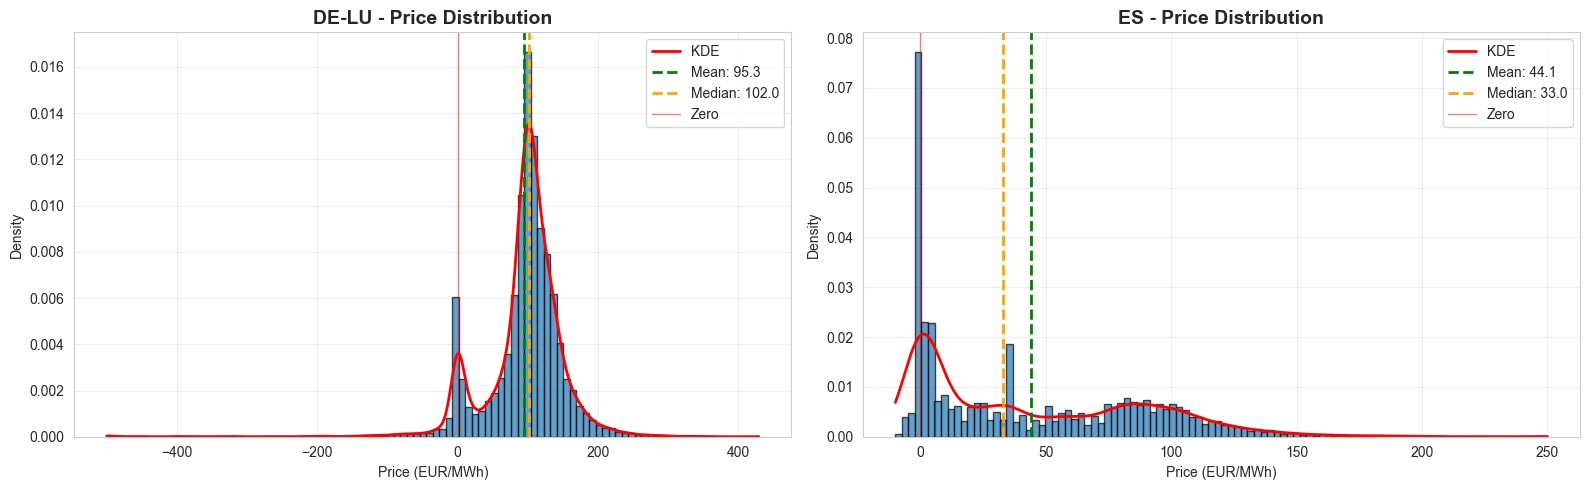


PRICE STATISTICS COMPARISON

DE-LU:
  Mean:     95.30 EUR/MWh
  Median:   101.98 EUR/MWh
  Std Dev:  57.25 EUR/MWh
  Min:      -499.99 EUR/MWh
  Max:      429.36 EUR/MWh
  Negative prices: 747 hours (6.27%)
  Skewness: -1.97
  Kurtosis: 15.55

ES:
  Mean:     44.13 EUR/MWh
  Median:   33.00 EUR/MWh
  Std Dev:  45.13 EUR/MWh
  Min:      -10.00 EUR/MWh
  Max:      250.00 EUR/MWh
  Negative prices: 1626 hours (13.66%)
  Skewness: 0.72
  Kurtosis: -0.36


In [17]:
# Price statistics comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, zone in enumerate(zones):
    df = data[zone]
    prices = df['price_eur_mwh']
    
    # Histogram with KDE
    axes[idx].hist(prices, bins=100, alpha=0.7, edgecolor='black', density=True)
    
    # Add KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(prices.dropna())
    x_range = np.linspace(prices.min(), prices.max(), 1000)
    axes[idx].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    
    axes[idx].axvline(prices.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {prices.mean():.1f}')
    axes[idx].axvline(prices.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {prices.median():.1f}')
    axes[idx].axvline(0, color='red', linestyle='-', linewidth=1, alpha=0.5, label='Zero')
    
    axes[idx].set_title(f'{zone} - Price Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Price (EUR/MWh)')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/eda_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*60)
print("PRICE STATISTICS COMPARISON")
print("="*60)

for zone in zones:
    prices = data[zone]['price_eur_mwh']
    print(f"\n{zone}:")
    print(f"  Mean:     {prices.mean():.2f} EUR/MWh")
    print(f"  Median:   {prices.median():.2f} EUR/MWh")
    print(f"  Std Dev:  {prices.std():.2f} EUR/MWh")
    print(f"  Min:      {prices.min():.2f} EUR/MWh")
    print(f"  Max:      {prices.max():.2f} EUR/MWh")
    print(f"  Negative prices: {(prices < 0).sum()} hours ({(prices < 0).mean()*100:.2f}%)")
    print(f"  Skewness: {prices.skew():.2f}")
    print(f"  Kurtosis: {prices.kurtosis():.2f}")

## 3. Temporal Patterns

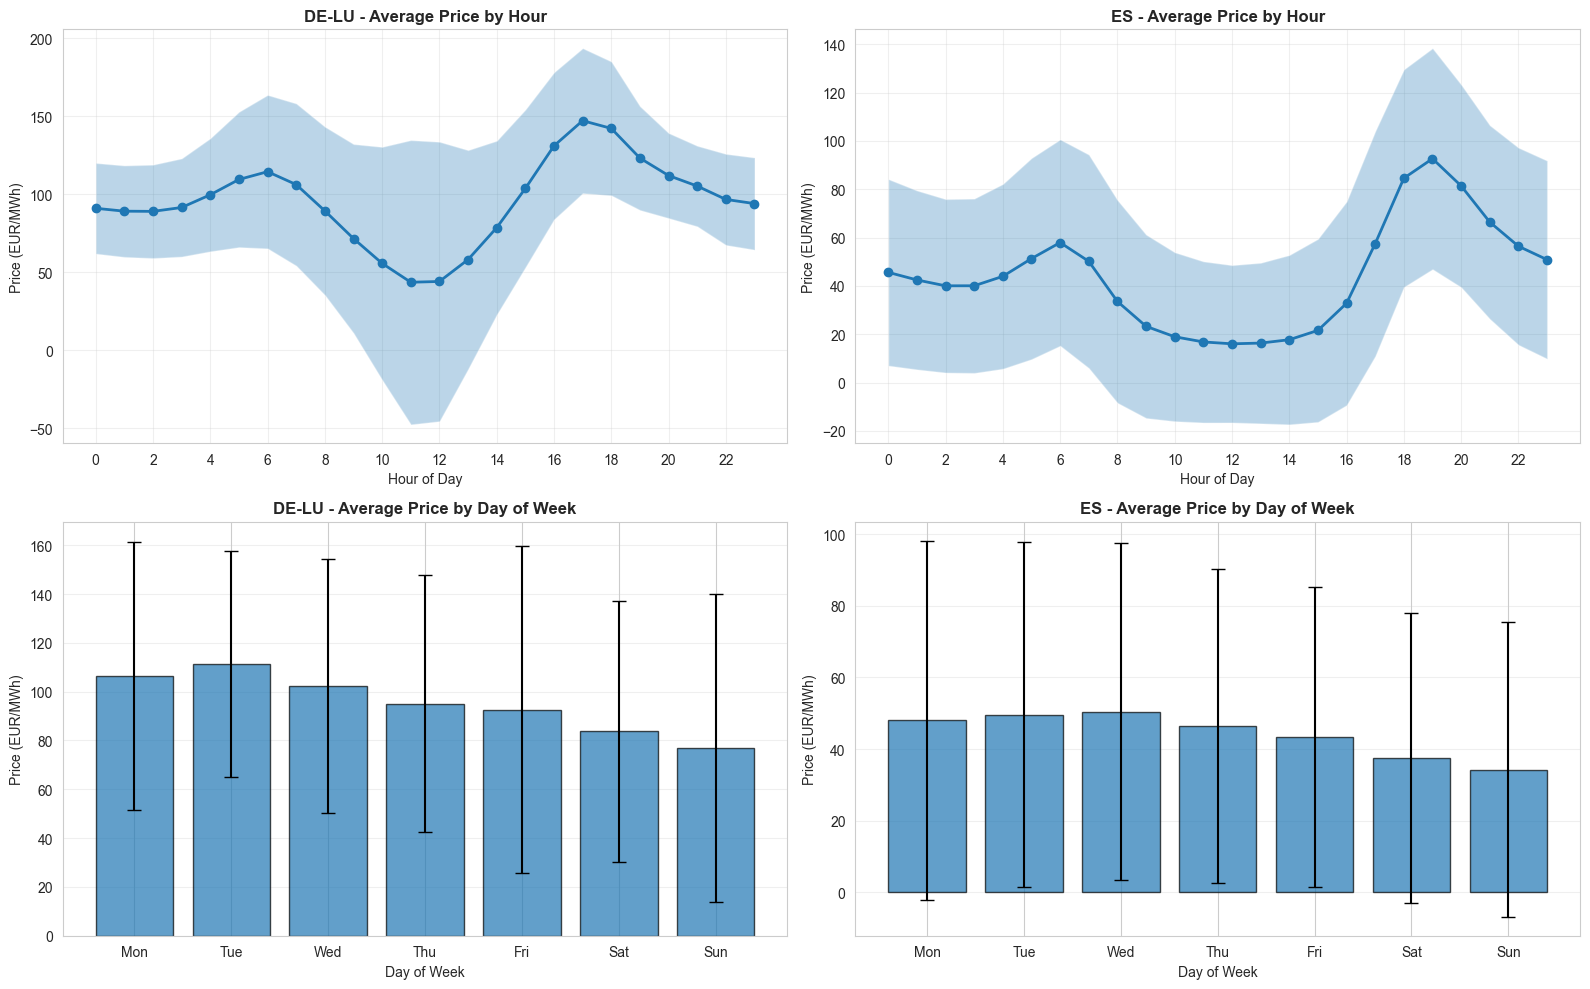

In [18]:
# Hourly patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, zone in enumerate(zones):
    df = data[zone]
    
    # Hourly average
    hourly_avg = df.groupby('hour')['price_eur_mwh'].agg(['mean', 'std'])
    axes[0, idx].plot(hourly_avg.index, hourly_avg['mean'], 'o-', linewidth=2, markersize=6)
    axes[0, idx].fill_between(hourly_avg.index, 
                               hourly_avg['mean'] - hourly_avg['std'],
                               hourly_avg['mean'] + hourly_avg['std'],
                               alpha=0.3)
    axes[0, idx].set_title(f'{zone} - Average Price by Hour', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Hour of Day')
    axes[0, idx].set_ylabel('Price (EUR/MWh)')
    axes[0, idx].grid(True, alpha=0.3)
    axes[0, idx].set_xticks(range(0, 24, 2))
    
    # Day of week average
    dow_avg = df.groupby('day_of_week')['price_eur_mwh'].agg(['mean', 'std'])
    dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    axes[1, idx].bar(range(7), dow_avg['mean'], yerr=dow_avg['std'], 
                     capsize=5, alpha=0.7, edgecolor='black')
    axes[1, idx].set_title(f'{zone} - Average Price by Day of Week', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Day of Week')
    axes[1, idx].set_ylabel('Price (EUR/MWh)')
    axes[1, idx].set_xticks(range(7))
    axes[1, idx].set_xticklabels(dow_labels)
    axes[1, idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/eda_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

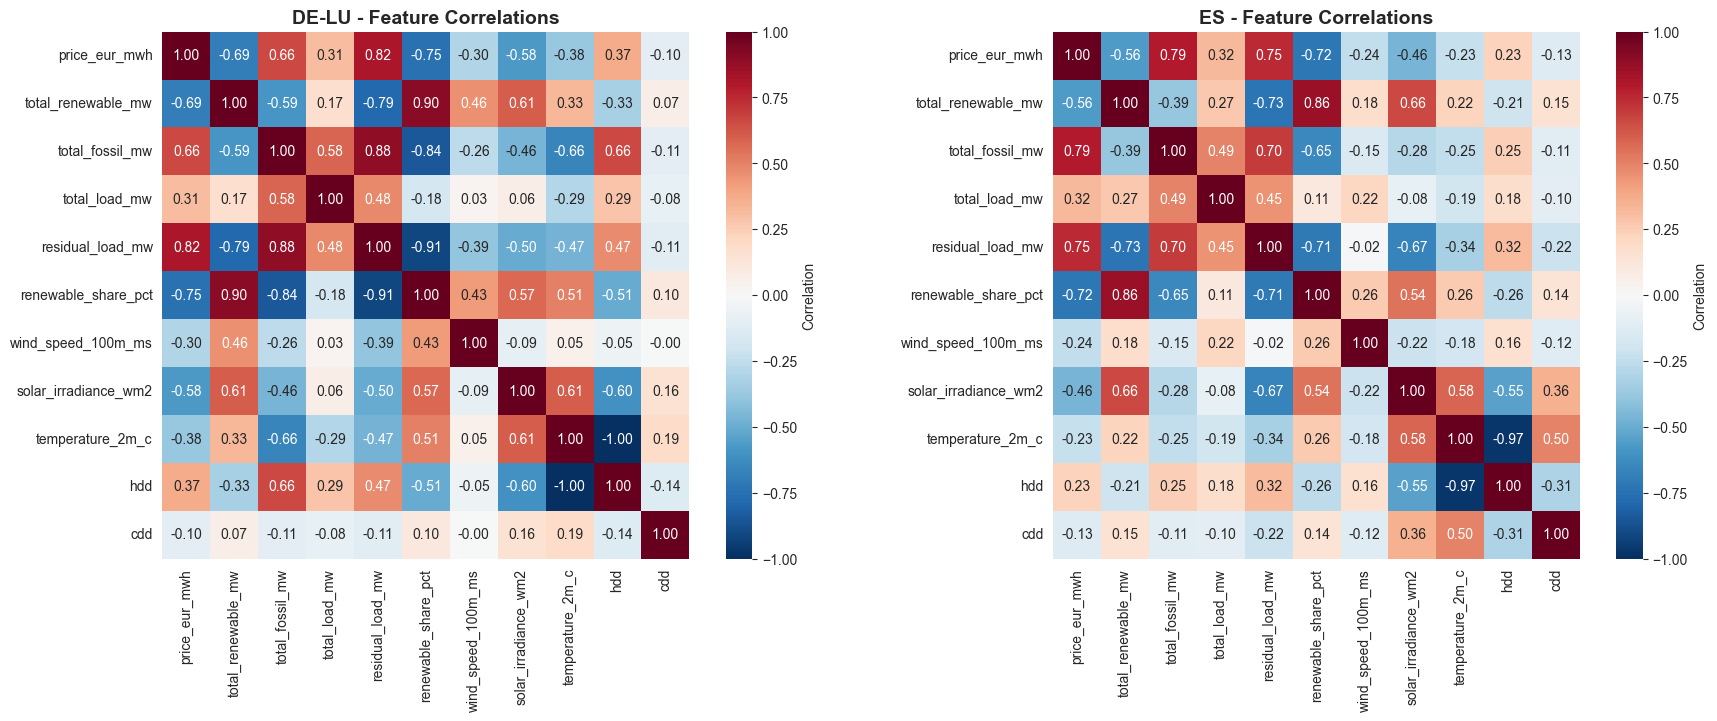


TOP CORRELATIONS WITH PRICE

DE-LU:
residual_load_mw        0.815132
total_fossil_mw         0.658508
hdd                     0.374428
total_load_mw           0.311935
cdd                    -0.104855
wind_speed_100m_ms     -0.297521
temperature_2m_c       -0.377646
solar_irradiance_wm2   -0.575681
total_renewable_mw     -0.692929
renewable_share_pct    -0.745887

ES:
total_fossil_mw         0.792012
residual_load_mw        0.745137
total_load_mw           0.324877
hdd                     0.227117
cdd                    -0.130057
temperature_2m_c       -0.230056
wind_speed_100m_ms     -0.242395
solar_irradiance_wm2   -0.462335
total_renewable_mw     -0.562584
renewable_share_pct    -0.724850


In [19]:
# Select key features for correlation analysis
key_features = [
    'price_eur_mwh',
    'total_renewable_mw', 'total_fossil_mw', 'total_load_mw', 'residual_load_mw',
    'renewable_share_pct', 'wind_speed_100m_ms', 'solar_irradiance_wm2',
    'temperature_2m_c', 'hdd', 'cdd'
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, zone in enumerate(zones):
    df = data[zone]
    
    # Select available features
    available_features = [f for f in key_features if f in df.columns]
    corr_data = df[available_features].corr()
    
    # Plot correlation heatmap
    sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, ax=axes[idx],
                cbar_kws={'label': 'Correlation'})
    axes[idx].set_title(f'{zone} - Feature Correlations', fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.savefig('../outputs/eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with price
print("\n" + "="*60)
print("TOP CORRELATIONS WITH PRICE")
print("="*60)

for zone in zones:
    df = data[zone]
    available_features = [f for f in key_features if f in df.columns]
    corr_with_price = df[available_features].corr()['price_eur_mwh'].drop('price_eur_mwh').sort_values(ascending=False)
    
    print(f"\n{zone}:")
    print(corr_with_price.to_string())

## 5. Renewable Generation vs Price

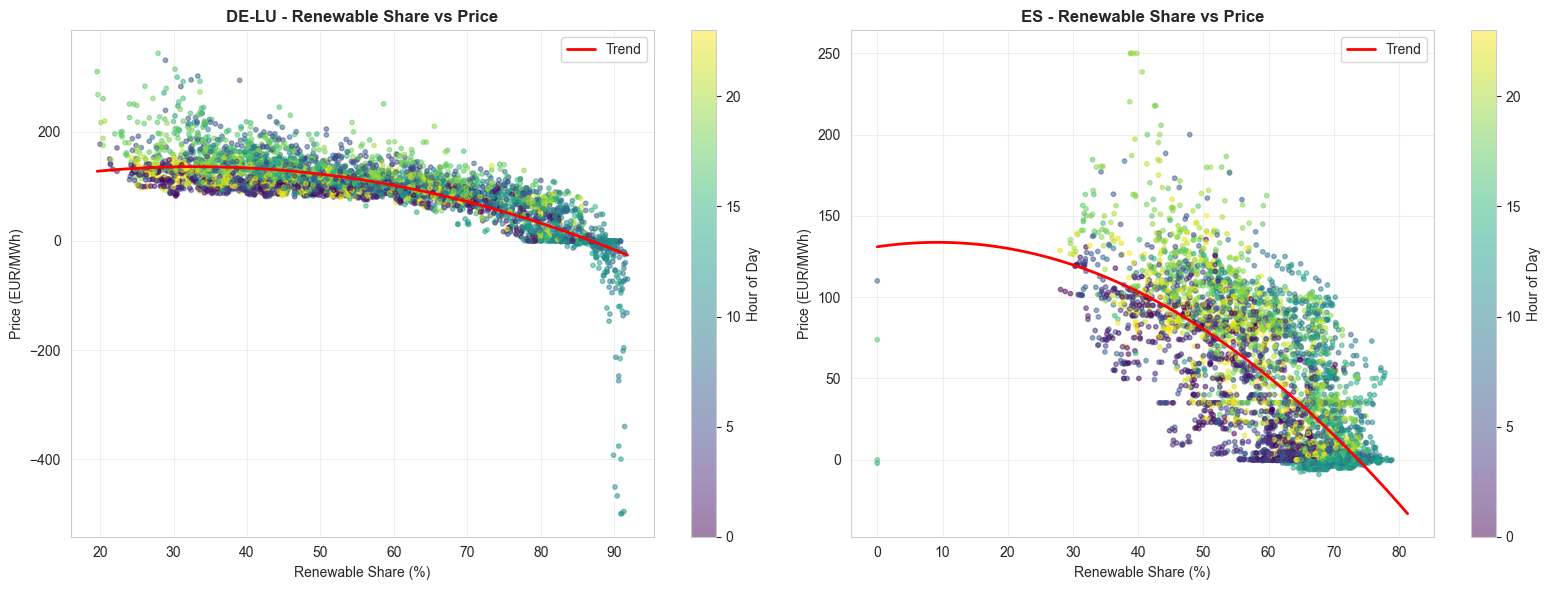

In [20]:
# Scatter plots: Renewable share vs Price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, zone in enumerate(zones):
    df = data[zone]
    
    if 'renewable_share_pct' in df.columns:
        # Sample data for better visualization
        sample = df.sample(min(5000, len(df)))
        
        scatter = axes[idx].scatter(sample['renewable_share_pct'], 
                                   sample['price_eur_mwh'],
                                   c=sample['hour'], cmap='viridis',
                                   alpha=0.5, s=10)
        
        # Add trend line
        z = np.polyfit(df['renewable_share_pct'].dropna(), 
                      df['price_eur_mwh'].dropna(), 2)
        p = np.poly1d(z)
        x_trend = np.linspace(df['renewable_share_pct'].min(), 
                             df['renewable_share_pct'].max(), 100)
        axes[idx].plot(x_trend, p(x_trend), 'r-', linewidth=2, label='Trend')
        
        axes[idx].set_title(f'{zone} - Renewable Share vs Price', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Renewable Share (%)')
        axes[idx].set_ylabel('Price (EUR/MWh)')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=axes[idx])
        cbar.set_label('Hour of Day')

plt.tight_layout()
plt.savefig('../outputs/eda_renewable_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Price Volatility Analysis

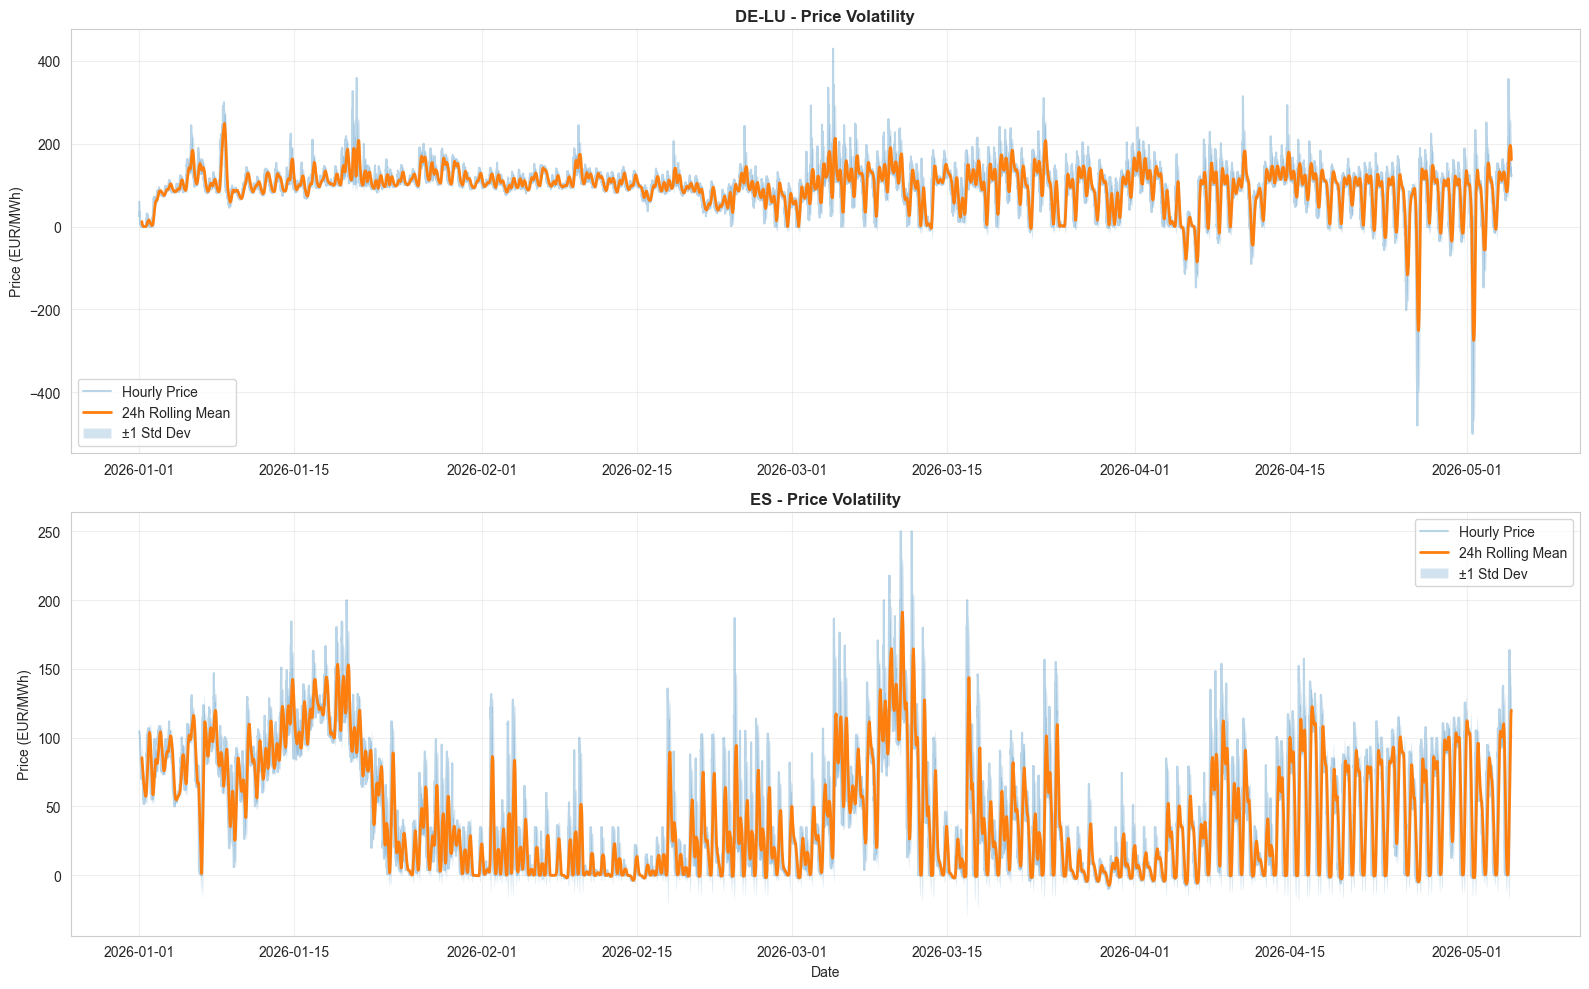

In [21]:
# Calculate rolling volatility
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for idx, zone in enumerate(zones):
    df = data[zone].copy()
    df = df.set_index('timestamp').sort_index()
    
    # Calculate rolling statistics
    df['price_rolling_mean_24h'] = df['price_eur_mwh'].rolling(window=24).mean()
    df['price_rolling_std_24h'] = df['price_eur_mwh'].rolling(window=24).std()
    
    # Plot price with rolling mean
    axes[idx].plot(df.index, df['price_eur_mwh'], alpha=0.3, label='Hourly Price')
    axes[idx].plot(df.index, df['price_rolling_mean_24h'], linewidth=2, label='24h Rolling Mean')
    axes[idx].fill_between(df.index,
                          df['price_rolling_mean_24h'] - df['price_rolling_std_24h'],
                          df['price_rolling_mean_24h'] + df['price_rolling_std_24h'],
                          alpha=0.2, label='±1 Std Dev')
    
    axes[idx].set_title(f'{zone} - Price Volatility', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Price (EUR/MWh)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../outputs/eda_price_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Insights Summary

In [24]:
print("\n" + "="*80)
print("KEY INSIGHTS FOR PRICE FORECASTING")
print("="*80)

for zone in zones:
    df = data[zone]
    prices = df['price_eur_mwh']
    
    print(f"\n{zone}:")
    print("-" * 40)
    
    # 1. Price characteristics
    print(f"\n1. PRICE CHARACTERISTICS:")
    print(f"   - Average: {prices.mean():.2f} EUR/MWh")
    print(f"   - Volatility (std): {prices.std():.2f} EUR/MWh")
    print(f"   - Negative prices: {(prices < 0).mean()*100:.2f}% of hours")
    print(f"   - Distribution: {'Right-skewed' if prices.skew() > 0 else 'Left-skewed'} (skew={prices.skew():.2f})")
    
    # 2. Temporal patterns
    print(f"\n2. TEMPORAL PATTERNS:")
    hourly_avg = df.groupby('hour')['price_eur_mwh'].mean()
    peak_hour = hourly_avg.idxmax()
    low_hour = hourly_avg.idxmin()
    print(f"   - Peak hour: {peak_hour}:00 ({hourly_avg[peak_hour]:.2f} EUR/MWh)")
    print(f"   - Low hour: {low_hour}:00 ({hourly_avg[low_hour]:.2f} EUR/MWh)")
    
    weekend_avg = df[df['is_weekend'] == 1]['price_eur_mwh'].mean()
    weekday_avg = df[df['is_weekend'] == 0]['price_eur_mwh'].mean()
    print(f"   - Weekend effect: {weekend_avg - weekday_avg:+.2f} EUR/MWh vs weekdays")
    
    # 3. Key correlations
    print(f"\n3. KEY CORRELATIONS WITH PRICE:")
    if 'renewable_share_pct' in df.columns:
        corr_renewable = df['price_eur_mwh'].corr(df['renewable_share_pct'])
        print(f"   - Renewable share: {corr_renewable:.3f}")
    if 'residual_load_mw' in df.columns:
        corr_residual = df['price_eur_mwh'].corr(df['residual_load_mw'])
        print(f"   - Residual load: {corr_residual:.3f}")
    if 'total_load_mw' in df.columns:
        corr_load = df['price_eur_mwh'].corr(df['total_load_mw'])
        print(f"   - Total load: {corr_load:.3f}")



KEY INSIGHTS FOR PRICE FORECASTING

DE-LU:
----------------------------------------

1. PRICE CHARACTERISTICS:
   - Average: 95.30 EUR/MWh
   - Volatility (std): 57.25 EUR/MWh
   - Negative prices: 6.27% of hours
   - Distribution: Left-skewed (skew=-1.97)

2. TEMPORAL PATTERNS:
   - Peak hour: 17:00 (147.17 EUR/MWh)
   - Low hour: 11:00 (43.63 EUR/MWh)
   - Weekend effect: -21.10 EUR/MWh vs weekdays

3. KEY CORRELATIONS WITH PRICE:
   - Renewable share: -0.746
   - Residual load: 0.815
   - Total load: 0.312

ES:
----------------------------------------

1. PRICE CHARACTERISTICS:
   - Average: 44.13 EUR/MWh
   - Volatility (std): 45.13 EUR/MWh
   - Negative prices: 13.66% of hours
   - Distribution: Right-skewed (skew=0.72)

2. TEMPORAL PATTERNS:
   - Peak hour: 19:00 (92.68 EUR/MWh)
   - Low hour: 12:00 (16.06 EUR/MWh)
   - Weekend effect: -11.66 EUR/MWh vs weekdays

3. KEY CORRELATIONS WITH PRICE:
   - Renewable share: -0.725
   - Residual load: 0.745
   - Total load: 0.325


## 8. Save Processed Data

In [ ]:
# Save merged datasets for next steps
for zone in zones:
    output_path = Path(f'../data/processed/{zone.lower()}_merged_with_features.csv')
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    data[zone].to_csv(output_path, index=False)
    print(f"Saved {zone} data to {output_path}")

print("\nAll data saved!")

✅ Saved DE-LU data to ..\data\processed\de-lu_merged_with_features.csv
✅ Saved ES data to ..\data\processed\es_merged_with_features.csv

✅ All data saved!
